In [12]:
# ════════════════════════════════════════════════════════════════════
# TITANIC — RANDOM FOREST PIPELINE
# ════════════════════════════════════════════════════════════════════
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

pipeline_start = time.time()


In [13]:
# ════════════════════════════════════════════════════════════════════
# 1. LOAD
# ════════════════════════════════════════════════════════════════════
t0 = time.time()

train = pd.read_csv('/kaggle/input/datasets/adnanmehdi911/dataset1/train.csv')
test  = pd.read_csv('/kaggle/input/datasets/adnanmehdi911/dataset1/test.csv')

passenger_ids = test['PassengerId'].copy()

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Survival rate: {train.Survived.mean():.3f}")
print(f"⏱ Load time: {time.time() - t0:.2f}s")



Train: (891, 12) | Test: (418, 11)
Survival rate: 0.384
⏱ Load time: 0.01s


In [14]:
# ════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════════════
t0 = time.time()

def engineer(df):
    df = df.copy()

    # ── Title ──────────────────────────────────────────────────────
    title_map = {
        'Mr': 1, 'Mrs': 2, 'Miss': 3, 'Ms': 3, 'Mlle': 3, 'Mme': 2,
        'Master': 4, 'Dr': 5, 'Rev': 5, 'Col': 5, 'Major': 5,
        'Capt': 5, 'Sir': 5, 'Lady': 5, 'Countess': 5,
        'Jonkheer': 5, 'Don': 5, 'Dona': 5
    }
    df['Title'] = (df['Name']
                   .str.extract(r', ([^\.]+)\.')[0]
                   .str.strip()
                   .map(title_map)
                   .fillna(5).astype(int))

    # ── Deck & cabin features ──────────────────────────────────────
    deck_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 8}
    df['Deck']        = df['Cabin'].fillna('U').str[0].map(deck_map).fillna(0).astype(int)
    df['Cabin_Known'] = df['Cabin'].notna().astype(int)
    df['Cabin_Count'] = df['Cabin'].fillna('').apply(lambda x: len(x.split()) if x else 0)

    # ── Family ─────────────────────────────────────────────────────
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    df['Is_Alone']    = (df['Family_Size'] == 1).astype(int)
    df['Family_Group'] = df['Family_Size'].apply(
        lambda x: 0 if x == 1 else (1 if x <= 4 else 2))

    # ── Fare ───────────────────────────────────────────────────────
    if df['Fare'].isna().any():
        df['Fare'] = df.groupby('Pclass')['Fare'].transform(
            lambda x: x.fillna(x.median()))
    df['Fare_Per_Person'] = df['Fare'] / df['Family_Size']
    df['Fare_Log']        = np.log1p(df['Fare'])
    df['Fare_Bin']        = pd.qcut(df['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)

    # ── Age ────────────────────────────────────────────────────────
    df['Age'] = df.groupby(['Pclass', 'Title'])['Age'].transform(
        lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Age_Band'] = pd.cut(
        df['Age'], bins=[0, 12, 18, 35, 60, 100],
        labels=[0, 1, 2, 3, 4]).astype(int)
    df['Age_x_Class'] = df['Age'] * df['Pclass']

    # ── Sex ────────────────────────────────────────────────────────
    df['Sex'] = (df['Sex'] == 'female').astype(int)

    # ── Embarked ───────────────────────────────────────────────────
    df['Embarked'] = df['Embarked'].fillna('S').map(
        {'C': 0, 'Q': 1, 'S': 2}).astype(int)

    # ── Ticket frequency ──────────────────────────────────────────
    ticket_counts    = df['Ticket'].value_counts()
    df['Ticket_Freq'] = df['Ticket'].map(ticket_counts).fillna(1).astype(int)

    # ── Pclass × Sex interaction ───────────────────────────────────
    df['Pclass_Sex'] = df['Pclass'] * 10 + df['Sex']

    # ── Drop raw columns ───────────────────────────────────────────
    df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'],
            inplace=True, errors='ignore')
    return df


train_fe = engineer(train)
test_fe  = engineer(test)

X = train_fe.drop('Survived', axis=1)
y = train_fe['Survived']
test_fe = test_fe[X.columns]

print(f"\nFeatures ({len(X.columns)}): {X.columns.tolist()}")
print(f"Missing in X:    {X.isnull().sum().sum()}")
print(f"Missing in test: {test_fe.isnull().sum().sum()}")
print(f"⏱ Feature engineering time: {time.time() - t0:.2f}s")




Features (21): ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Deck', 'Cabin_Known', 'Cabin_Count', 'Family_Size', 'Is_Alone', 'Family_Group', 'Fare_Per_Person', 'Fare_Log', 'Fare_Bin', 'Age_Band', 'Age_x_Class', 'Ticket_Freq', 'Pclass_Sex']
Missing in X:    0
Missing in test: 0
⏱ Feature engineering time: 0.04s


In [15]:
# ════════════════════════════════════════════════════════════════════
# 3. MODEL
# ════════════════════════════════════════════════════════════════════
rf = RandomForestClassifier(
    n_estimators=500, max_depth=7,
    min_samples_split=4, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)






In [16]:
# ════════════════════════════════════════════════════════════════════
# 4. CROSS-VALIDATION
# ════════════════════════════════════════════════════════════════════
t0 = time.time()

cv     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("\n" + "=" * 45)
print("RANDOM FOREST — 10-Fold CV Results")
print("=" * 45)
print(f"CV Mean : {scores.mean():.4f}")
print(f"CV Std  : {scores.std():.4f}")
print(f"CV Min  : {scores.min():.4f}")
print(f"CV Max  : {scores.max():.4f}")
print(f"⏱ CV time: {time.time() - t0:.2f}s")



RANDOM FOREST — 10-Fold CV Results
CV Mean : 0.8282
CV Std  : 0.0346
CV Min  : 0.7640
CV Max  : 0.8876
⏱ CV time: 4.59s


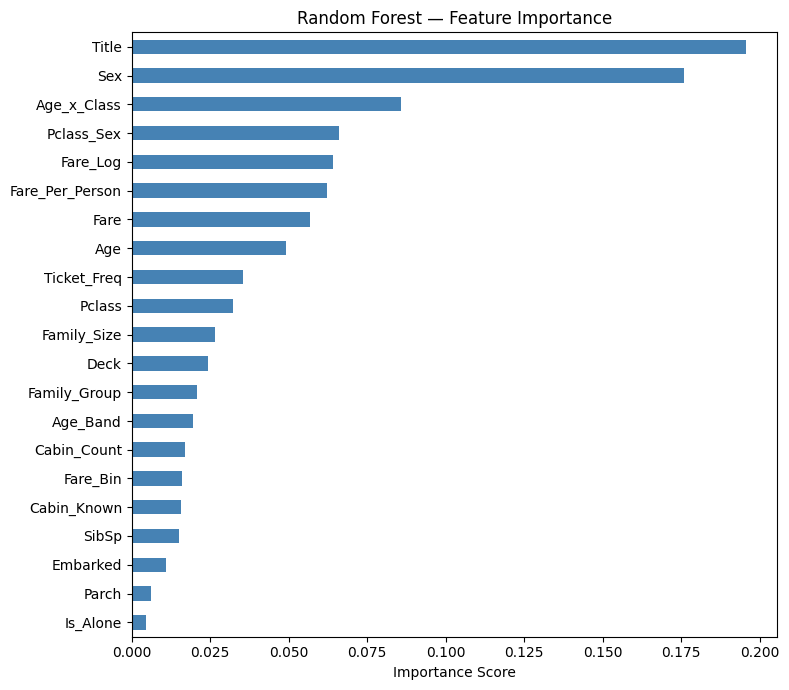

⏱ Feature importance plot time: 1.33s


In [17]:
# ════════════════════════════════════════════════════════════════════
# 5. FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════════════
t0 = time.time()

rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 7))
imp.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f"⏱ Feature importance plot time: {time.time() - t0:.2f}s")

In [18]:
# ════════════════════════════════════════════════════════════════════
# 6. PREDICT & SAVE SUBMISSION
# ════════════════════════════════════════════════════════════════════
t0 = time.time()

train_acc   = accuracy_score(y, rf.predict(X))
predictions = rf.predict(test_fe)

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived':    predictions
})
submission.to_csv('submission.csv', index=False)

print("\n" + "=" * 45)
print(f"Train accuracy          : {train_acc:.4f}")
print(f"CV accuracy             : {scores.mean():.4f}")
print(f"Overfit gap             : {train_acc - scores.mean():.4f} ")
print(f"Predicted survival rate : {predictions.mean():.3f} ")
print(f"⏱ Predict + save time: {time.time() - t0:.2f}s")

print("\nSample predictions:")
print(submission.head(10).to_string(index=False))

print("\n" + "=" * 45)
print(f"⏱ Total pipeline time: {time.time() - pipeline_start:.2f}s")
print("=" * 45)


Train accuracy          : 0.8878
CV accuracy             : 0.8282
Overfit gap             : 0.0595 
Predicted survival rate : 0.404 
⏱ Predict + save time: 0.29s

Sample predictions:
 PassengerId  Survived
         892         0
         893         0
         894         0
         895         0
         896         1
         897         0
         898         1
         899         0
         900         1
         901         0

⏱ Total pipeline time: 6.32s


Train: (891, 12) | Test: (418, 11)
Survival rate: 0.384
⏱  Load: 0.015s

Features (21): ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Deck', 'Cabin_Known', 'Cabin_Count', 'Family_Size', 'Is_Alone', 'Family_Group', 'Fare_Per_Person', 'Fare_Log', 'Fare_Bin', 'Age_Band', 'Age_x_Class', 'Ticket_Freq', 'Pclass_Sex']
Missing in X:    0
Missing in test: 0
⏱  Feature engineering: 0.038s

Compiling JIT functions (one-time cost)... done in 1.54s

═══════════════════════════════════════════════════════
PIPELINE A — BASELINE Random Forest
═══════════════════════════════════════════════════════
CV Mean  : 0.8282
CV Std   : 0.0346
Train Acc: 0.8878
Overfit  : 0.0595
⏱  CV time          : 6.658s
⏱  Fit+predict time : 1.208s
⏱  TOTAL A          : 7.866s

═══════════════════════════════════════════════════════
PIPELINE B — JIT-Accelerated (Numba + Random Forest)
═══════════════════════════════════════════════════════
⏱  JIT preprocessing: 0.0011s
CV Mean  : 0.8282
CV Std   : 

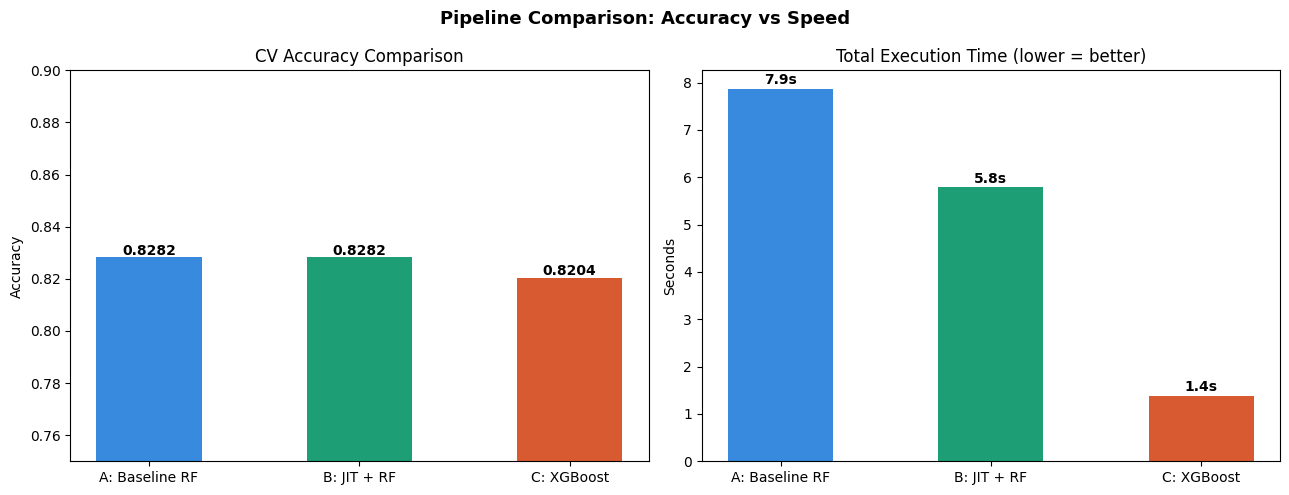


 Best model: A: Baseline RF  (CV=0.8282)
   Predicted survival rate: 0.404  (train was 0.384)
   submission.csv saved — 418 rows
 PassengerId  Survived
         892         0
         893         0
         894         0
         895         0
         896         1
         897         0
         898         1
         899         0
         900         1
         901         0


In [22]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from numba import njit, prange
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

pipeline_start = time.time()
timing = {} 

t0 = time.time()

train = pd.read_csv('/kaggle/input/datasets/adnanmehdi911/dataset1/train.csv')
test  = pd.read_csv('/kaggle/input/datasets/adnanmehdi911/dataset1/test.csv')

passenger_ids = test['PassengerId'].copy()

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Survival rate: {train.Survived.mean():.3f}")
timing['1_load'] = time.time() - t0
print(f"⏱  Load: {timing['1_load']:.3f}s")


t0 = time.time()

def engineer(df):
    df = df.copy()

    title_map = {
        'Mr': 1, 'Mrs': 2, 'Miss': 3, 'Ms': 3, 'Mlle': 3, 'Mme': 2,
        'Master': 4, 'Dr': 5, 'Rev': 5, 'Col': 5, 'Major': 5,
        'Capt': 5, 'Sir': 5, 'Lady': 5, 'Countess': 5,
        'Jonkheer': 5, 'Don': 5, 'Dona': 5
    }
    df['Title'] = (df['Name']
                   .str.extract(r', ([^\.]+)\.')[0]
                   .str.strip()
                   .map(title_map)
                   .fillna(5).astype(int))

    deck_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 8}
    df['Deck']         = df['Cabin'].fillna('U').str[0].map(deck_map).fillna(0).astype(int)
    df['Cabin_Known']  = df['Cabin'].notna().astype(int)
    df['Cabin_Count']  = df['Cabin'].fillna('').apply(lambda x: len(x.split()) if x else 0)

    df['Family_Size']  = df['SibSp'] + df['Parch'] + 1
    df['Is_Alone']     = (df['Family_Size'] == 1).astype(int)
    df['Family_Group'] = df['Family_Size'].apply(
        lambda x: 0 if x == 1 else (1 if x <= 4 else 2))

    if df['Fare'].isna().any():
        df['Fare'] = df.groupby('Pclass')['Fare'].transform(
            lambda x: x.fillna(x.median()))
    df['Fare_Per_Person'] = df['Fare'] / df['Family_Size']
    df['Fare_Log']        = np.log1p(df['Fare'])
    df['Fare_Bin']        = pd.qcut(df['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)

    df['Age'] = df.groupby(['Pclass', 'Title'])['Age'].transform(
        lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Age_Band'] = pd.cut(
        df['Age'], bins=[0, 12, 18, 35, 60, 100],
        labels=[0, 1, 2, 3, 4]).astype(int)
    df['Age_x_Class']  = df['Age'] * df['Pclass']

    df['Sex']      = (df['Sex'] == 'female').astype(int)
    df['Embarked'] = df['Embarked'].fillna('S').map({'C': 0, 'Q': 1, 'S': 2}).astype(int)

    ticket_counts     = df['Ticket'].value_counts()
    df['Ticket_Freq'] = df['Ticket'].map(ticket_counts).fillna(1).astype(int)
    df['Pclass_Sex']  = df['Pclass'] * 10 + df['Sex']

    df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'],
            inplace=True, errors='ignore')
    return df


train_fe = engineer(train)
test_fe  = engineer(test)

X        = train_fe.drop('Survived', axis=1)
y        = train_fe['Survived']
test_fe  = test_fe[X.columns]

# Convert to numpy arrays once — used by JIT functions below
X_np     = X.values.astype(np.float64)
y_np     = y.values.astype(np.float64)
test_np  = test_fe.values.astype(np.float64)

timing['2_feature_eng'] = time.time() - t0
print(f"\nFeatures ({len(X.columns)}): {X.columns.tolist()}")
print(f"Missing in X:    {X.isnull().sum().sum()}")
print(f"Missing in test: {test_fe.isnull().sum().sum()}")
print(f"⏱  Feature engineering: {timing['2_feature_eng']:.3f}s")


@njit(parallel=True)
def jit_standardize(X):
    """Z-score each column in parallel using Numba JIT."""
    out  = np.empty_like(X)
    cols = X.shape[1]
    for j in prange(cols):
        col  = X[:, j]
        mu   = col.mean()
        std  = col.std()
        if std == 0.0:
            std = 1.0
        out[:, j] = (col - mu) / std
    return out

@njit(parallel=True)
def jit_compute_feature_stats(X, y):
    """Compute per-feature mean for survived=1 vs 0 in parallel."""
    n_features = X.shape[1]
    mean_surv   = np.zeros(n_features)
    mean_nosurv = np.zeros(n_features)
    for j in prange(n_features):
        s_sum = 0.0; s_cnt = 0
        n_sum = 0.0; n_cnt = 0
        for i in range(X.shape[0]):
            if y[i] == 1:
                s_sum += X[i, j]; s_cnt += 1
            else:
                n_sum += X[i, j]; n_cnt += 1
        mean_surv[j]   = s_sum / s_cnt   if s_cnt   > 0 else 0.0
        mean_nosurv[j] = n_sum / n_cnt   if n_cnt   > 0 else 0.0
    return mean_surv, mean_nosurv

print("\nCompiling JIT functions (one-time cost)...", end=' ')
t_jit_compile = time.time()
_ = jit_standardize(X_np[:10].copy())
_ = jit_compute_feature_stats(X_np[:10].copy(), y_np[:10].copy())
print(f"done in {time.time() - t_jit_compile:.2f}s")

print("\n" + "═" * 55)
print("PIPELINE A — BASELINE Random Forest")
print("═" * 55)

t0  = time.time()
rf_base = RandomForestClassifier(
    n_estimators=500, max_depth=7,
    min_samples_split=4, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)

cv      = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_base = cross_val_score(rf_base, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
timing['A_cv'] = time.time() - t0

t0 = time.time()
rf_base.fit(X, y)
preds_base    = rf_base.predict(test_fe)
timing['A_fit_predict'] = time.time() - t0

timing['A_total'] = timing['A_cv'] + timing['A_fit_predict']

print(f"CV Mean  : {scores_base.mean():.4f}")
print(f"CV Std   : {scores_base.std():.4f}")
print(f"Train Acc: {accuracy_score(y, rf_base.predict(X)):.4f}")
print(f"Overfit  : {accuracy_score(y, rf_base.predict(X)) - scores_base.mean():.4f}")
print(f"⏱  CV time          : {timing['A_cv']:.3f}s")
print(f"⏱  Fit+predict time : {timing['A_fit_predict']:.3f}s")
print(f"⏱  TOTAL A          : {timing['A_total']:.3f}s")

print("\n" + "═" * 55)
print("PIPELINE B — JIT-Accelerated (Numba + Random Forest)")
print("═" * 55)

# JIT preprocessing
t0 = time.time()
X_jit      = jit_standardize(X_np.copy())
test_jit   = jit_standardize(test_np.copy())
ms, mn     = jit_compute_feature_stats(X_jit, y_np)
timing['B_jit_preprocess'] = time.time() - t0
print(f"⏱  JIT preprocessing: {timing['B_jit_preprocess']:.4f}s")

# CV
t0 = time.time()
rf_jit = RandomForestClassifier(
    n_estimators=500, max_depth=7,
    min_samples_split=4, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)

scores_jit = cross_val_score(rf_jit, X_jit, y, cv=cv, scoring='accuracy', n_jobs=-1)
timing['B_cv'] = time.time() - t0

t0 = time.time()
rf_jit.fit(X_jit, y)
preds_jit  = rf_jit.predict(test_jit)
timing['B_fit_predict'] = time.time() - t0

timing['B_total'] = timing['B_jit_preprocess'] + timing['B_cv'] + timing['B_fit_predict']

print(f"CV Mean  : {scores_jit.mean():.4f}")
print(f"CV Std   : {scores_jit.std():.4f}")
print(f"Train Acc: {accuracy_score(y, rf_jit.predict(X_jit)):.4f}")
print(f"Overfit  : {accuracy_score(y, rf_jit.predict(X_jit)) - scores_jit.mean():.4f}")
print(f"⏱  CV time          : {timing['B_cv']:.3f}s")
print(f"⏱  Fit+predict time : {timing['B_fit_predict']:.3f}s")
print(f"⏱  TOTAL B          : {timing['B_total']:.3f}s")

print("\n" + "═" * 55)
print("PIPELINE C — Gradient-Based (XGBoost)")
print("═" * 55)

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=500, max_depth=4,
    learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    eval_metric='logloss', tree_method='hist',   # histogram = faster gradient steps
    random_state=42, n_jobs=-1, verbosity=0)

scores_xgb = cross_val_score(xgb, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
timing['C_cv'] = time.time() - t0

t0 = time.time()
xgb.fit(X, y)
preds_xgb  = xgb.predict(test_fe)
timing['C_fit_predict'] = time.time() - t0

timing['C_total'] = timing['C_cv'] + timing['C_fit_predict']

print(f"CV Mean  : {scores_xgb.mean():.4f}")
print(f"CV Std   : {scores_xgb.std():.4f}")
print(f"Train Acc: {accuracy_score(y, xgb.predict(X)):.4f}")
print(f"Overfit  : {accuracy_score(y, xgb.predict(X)) - scores_xgb.mean():.4f}")
print(f"⏱  CV time          : {timing['C_cv']:.3f}s")
print(f"⏱  Fit+predict time : {timing['C_fit_predict']:.3f}s")
print(f"⏱  TOTAL C          : {timing['C_total']:.3f}s")

import sys

print("\n" + "═" * 65)
print(f"{'FINAL COMPARISON':^65}")
print("═" * 65)
print(f"{'Pipeline':<30}  {'CV Acc':>7}  {'Std':>6}  {'Time':>8}  {'Speedup':>8}")
print("─" * 65)
sys.stdout.flush()

pipelines = [
    ("A — Baseline RF",        scores_base.mean(), scores_base.std(), timing['A_total']),
    ("B — JIT + RF",           scores_jit.mean(),  scores_jit.std(),  timing['B_total']),
    ("C — Gradient (XGBoost)", scores_xgb.mean(),  scores_xgb.std(),  timing['C_total']),
]

base_time = timing['A_total']

for name, cv_mean, cv_std, t in pipelines:
    try:
        speedup = base_time / t if t > 0 else float('inf')
        print(f"{name:<30}  {cv_mean:.4f}   {cv_std:.4f}  {t:>7.2f}s  {speedup:>7.2f}x")
        sys.stdout.flush()
    except Exception as e:
        print(f"{name:<30}  ERROR: {e}")
        sys.stdout.flush()

print("═" * 65)
print("\n── Detailed breakdown ──────────────────────────────────────")
for key, val in sorted(timing.items()):
    print(f"  {key:<30} : {val:.4f}s")
sys.stdout.flush()

print(f"\n⏱  Total wall-clock time: {time.time() - pipeline_start:.2f}s")
sys.stdout.flush()

print("\n── Overfit check ───────────────────────────────────────────")
for name, scores, train_a in [
    ("A Baseline RF",  scores_base, accuracy_score(y, rf_base.predict(X))),
    ("B JIT + RF",     scores_jit,  accuracy_score(y, rf_jit.predict(X_jit))),
    ("C XGBoost Grad", scores_xgb,  accuracy_score(y, xgb.predict(X))),
]:
    gap = train_a - scores.mean()
    flag = " OVERFIT" if gap > 0.06 else "healthy"
    print(f"  {name:<22}  train={train_a:.4f}  CV={scores.mean():.4f}  "
          f"gap={gap:.4f}  {flag}")
sys.stdout.flush()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels   = ['A: Baseline RF', 'B: JIT + RF', 'C: XGBoost']
cv_means = [scores_base.mean(), scores_jit.mean(), scores_xgb.mean()]
times    = [timing['A_total'],  timing['B_total'], timing['C_total']]
colors   = ['#378add', '#1d9e75', '#d85a30']

axes[0].bar(labels, cv_means, color=colors, width=0.5)
axes[0].set_ylim(0.75, 0.90)
axes[0].set_title('CV Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(cv_means):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(labels, times, color=colors, width=0.5)
axes[1].set_title('Total Execution Time (lower = better)')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.1, f'{v:.1f}s', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Pipeline Comparison: Accuracy vs Speed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
sys.stdout.flush()

best_idx   = cv_means.index(max(cv_means))
best_preds = [preds_base, preds_jit, preds_xgb][best_idx]
best_name  = labels[best_idx]

submission = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': best_preds})
submission.to_csv('submission.csv', index=False)

print(f"\n Best model: {best_name}  (CV={cv_means[best_idx]:.4f})")
print(f"   Predicted survival rate: {best_preds.mean():.3f}  (train was 0.384)")
print(f"   submission.csv saved — {len(submission)} rows")
print(submission.head(10).to_string(index=False))
sys.stdout.flush()